In [1]:
%matplotlib widget

import lmfit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from tqdm.notebook import tqdm
import xarray as xr

from TASsello import convert_E_to_I

def sci_notation(val, precision=1):
    exp = int(np.floor(np.log10(val)))
    mant = val / 10**exp
    return fr"${mant:.{precision}f} \times 10^{{{exp}}}$"

In [2]:
focus = [10, 15, 20, 25, 30, 35, 40, 45]

pelabel = [0.3, 8.8, 20.1, 67.4, 142.5]
pump_energy = ['0.043', '3.956', '8.514', '28.423', '62.178']

hw_L3 = 932.7

In [3]:
exports_name = [
    'M_220706E1_Z_0.3_',
    'M_220706E1_Z_10_',
    'M_220706E1_Z_25_',
    'M_220706E1_Z_50_',
    'M_220706E1_Z_100_',    
]

# RESULTS FROM A SINGLE FOCUS SIZE

In [4]:
ifoc = 2

folder = './sources/self_consistent_results'
folderpath = f'{folder}/{focus[ifoc]}um/h5'

In [5]:
measurement = {pe: xr.open_dataset(f'XFEL_exports/{exports_name[i]}.h5', engine='h5netcdf')
               for i, pe in enumerate(pump_energy)
              }

simulation = {}
for i, pe in enumerate(tqdm(pump_energy)):
    filepath = f'{folderpath}/{pe}.h5'
    simulation[pe] = xr.open_dataset(filepath, engine='h5netcdf')
    simulation[pe]['R_all'] = simulation[pe]['R_sim'] * \
                              simulation[pe]['spectrum_norm'] * \
                              simulation[pe]['field_norm'] * \
                              simulation[pe]['grid_weights']
    simulation[pe]['R_all'] = simulation[pe]['R_all'].sum(dim=('x','y','t'))

    # Re-normalize to unitary area after L3 edge
    hw_max = min(simulation[pe].energy[-1], measurement[pe].energy[-1])

    norm_sim = [
        np.trapezoid(
            simulation[pe]['R_all'].sel(alpha=a).sel(energy=slice(hw_L3, hw_max)),
            x=simulation[pe]['energy'].sel(energy=slice(hw_L3, hw_max))
            )
        for a in simulation[pe].alpha
    ]
    simulation[pe]['renorm'] = ('alpha', norm_sim)
    
    norm_mes = np.trapezoid(
        measurement[pe]['spectrum_avg'].sel(energy=slice(hw_L3, hw_max)),
        measurement[pe]['energy'].sel(energy=slice(hw_L3, hw_max))
    )

    simulation[pe]['R_all_renorm'] = simulation[pe]['R_all'] / simulation[pe]['renorm']
    measurement[pe]['spectrum_avg_renorm'] = measurement[pe]['spectrum_avg'] / norm_mes
    measurement[pe]['spectrum_std_renorm'] = measurement[pe]['spectrum_std'] / norm_mes

  0%|          | 0/5 [00:00<?, ?it/s]

## Find optimal alpha

[96 50 13 97 95 69 14  3 51 98]
[79 80 78 81 82 77 83 84 76 85]
[45 46 47 88 89 44 48 87 75 90]
[48 47 89 45 44 90 46 88 76 49]
[85 86 77 84 76 87 83 78 82 88]


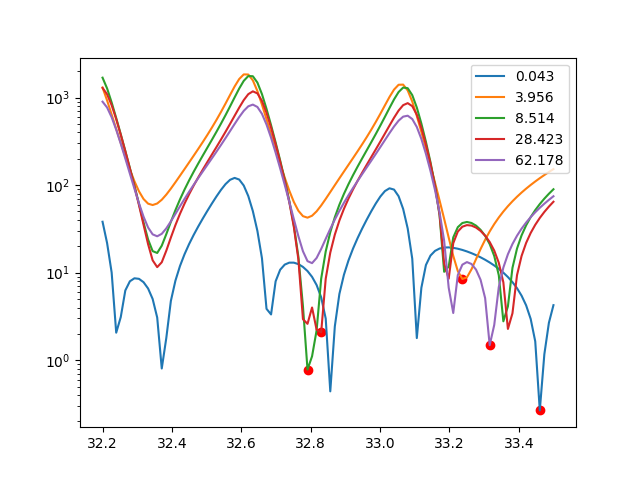

[array(33.46060606),
 array(33.23737374),
 array(32.79090909),
 array(32.83030303),
 array(33.31616162)]

In [6]:
plt.figure()
alpha_optimal = []
restot = np.zeros_like(simulation[pe].alpha.values)
for pe in pump_energy:
    resids = []
    for a in simulation[pe].alpha:
        R_all_renorm_interp = np.interp(
            measurement[pe]['spectrum_avg_renorm']['energy'].values,
            simulation[pe]['R_all_renorm']['energy'].values,
            simulation[pe]['R_all_renorm'].sel(alpha=a).values
        )
        
        resids.append(
            np.sqrt(
                np.sum(
                    R_all_renorm_interp - measurement[pe]['spectrum_avg_renorm'].values
                )**2
            )
        )

    idx = np.argmin(resids)
    plt.plot(simulation[pe].alpha, resids, label=pe)
    plt.scatter(simulation[pe].alpha[idx], resids[idx], color='r')

    alpha_optimal.append(simulation[pe].alpha[idx].values)

    restot += resids

    print(np.argsort(resids)[:10])
    
plt.yscale('log')
plt.legend()
plt.show()

alpha_optimal

In [7]:
[2*a for a in alpha_optimal]

[np.float64(66.92121212121212),
 np.float64(66.47474747474747),
 np.float64(65.58181818181818),
 np.float64(65.66060606060606),
 np.float64(66.63232323232323)]

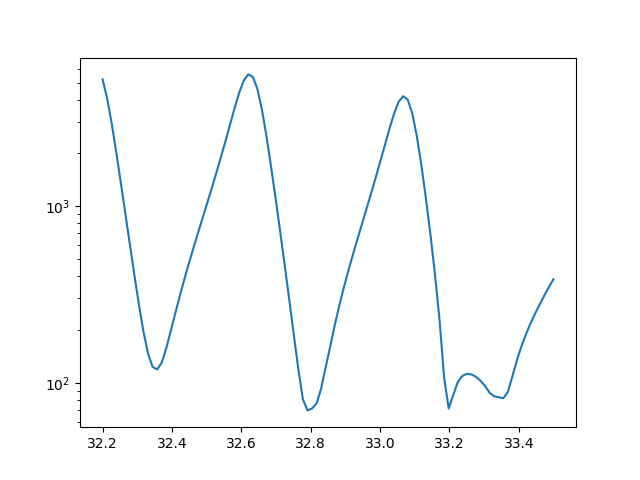

np.int64(45)

In [8]:
plt.figure()
plt.plot(simulation[pe].alpha, restot)
plt.yscale('log')
plt.show()
np.argmin(restot)

In [9]:
a = simulation[pe].alpha[13] #+ 0.05
dalpha = 0.05
simplot = {pe: simulation[pe].sel(alpha=a, method='nearest') for pe in pump_energy}

In [10]:
a

<xarray.DataArray 'alpha' ()> Size: 8B
array(32.37070707)
Coordinates:
    alpha    float64 8B 32.37

# Plot

In [11]:
colors = plt.colormaps['plasma'](np.linspace(0.1,0.8,len(pump_energy)))

shift = 3

In [12]:
plt.rcParams.update({
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'font.size': 16,
})

  0%|          | 0/5 [00:00<?, ?it/s]

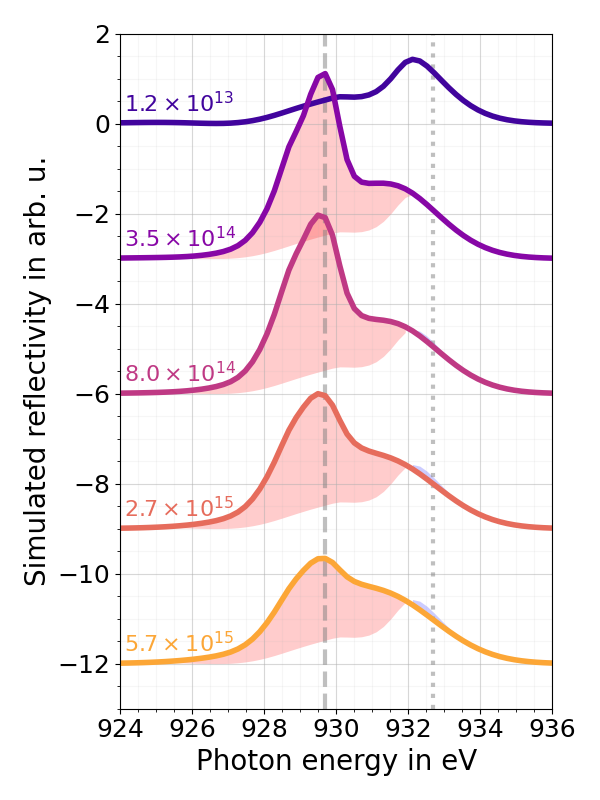

In [14]:
fig, axT = plt.subplots(nrows=1, ncols=1, figsize=(6,8), sharey=True)

for ax in [axT]:
    ax.axvline(929.7, c='grey', ls='--', lw=3, alpha=0.5, label=r'Cu-$L_\alpha$ (929.7 eV)')
    ax.axvline(932.7, c='grey', ls=':', lw=3, alpha=0.5, label=r'Cu-$L_3$ (932.7 eV)')

for i, pe in enumerate(tqdm(pump_energy)):  
    diff = simplot[pe]['R_all_renorm'] - simplot[pump_energy[0]]['R_all_renorm']
    Pdiff = diff.where(diff>0, drop=True).where(diff.energy<933.5, drop=True)
    Ndiff = diff.where(diff<0, drop=True).where(diff.energy>930, drop=True).where(diff.energy<934, drop=True)

    axT.fill_between(simplot[pe]['energy'].sel(energy=Pdiff.energy),
                     simplot[pe]['R_all_renorm'].sel(energy=Pdiff.energy) - i*shift,
                     simplot[pump_energy[0]]['R_all_renorm'].sel(energy=Pdiff.energy) - i*shift,
                     lw=0, alpha=0.2, color='r')
    axT.fill_between(simplot[pe]['energy'].sel(energy=Ndiff.energy),
                     simplot[pump_energy[0]]['R_all_renorm'].sel(energy=Ndiff.energy) - i*shift,
                     simplot[pe]['R_all_renorm'].sel(energy=Ndiff.energy) - i*shift,
                     lw=0, alpha=0.2, color='b')
    
    label = sci_notation(convert_E_to_I(float(pelabel[i])*1e-6, focus[ifoc], 15))
    theory = {'color': colors[i], 'ls': '-', 'lw': 4}
    meas = {'color': 'w', 'ls': '-', 'lw': 2}#, 'label': label
    
    (simplot[pe]['R_all_renorm'] - i*shift).plot(**theory, ax=axT)

   
    axT.text(924.1, -i*shift+0.25, label,
            # fontweight='demibold',
            color=colors[i])

axT.set_ylabel('Simulated reflectivity in arb. u.')
# axM.set_yticks(np.arange(3, -15, -3))
for ax in [axT]:
    ax.set_xticks(np.arange(920, 942, 2))   
    ax.set_xlim(924, 936)
    ax.set_ylim(-13, 2)
    ax.set_xlabel('Photon energy in eV')
    ax.minorticks_on()
    ax.grid(which='both', alpha=0.1)
    ax.grid(which='major', alpha=0.5)

axT.set_title('')

plt.tight_layout()
plt.show()

# plt.savefig(f'{folder}/img_theory_only.pdf', bbox_inches='tight')